#환경 설정 및 데이터 로드 
분석을 위해 필요한 파이썬 라이브러리를 불러오고 데이터를 읽기

목표: 우주선 Titanic호가 시공간 이상 현상과 충돌했을 때, 승객이 다른 차원으로 이동(Transported)했는지 여부를 예측하는 것

##라이브러리 임포트
분석에 필요한 데이터 처리(pandas, numpy), 시각화(seaborn, matplotlib), 그리고 머신러닝 모델 학습을 위한 tensorflow 관련 라이브러리들을 불러오기

In [8]:
mkdir -p ~/work/spaceship-titanic 

In [9]:
!find /home/jovyan -name "train.csv"

/home/jovyan/data/data/train.csv
/home/jovyan/work/spaceship-titanic/train.csv
/home/jovyan/work/kaggle_kakr_housing/data/train.csv


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 시각화용
import seaborn as sns
import matplotlib.pyplot as plt

##데이터 불러오기

In [34]:
file_path = '/home/jovyan/work/spaceship-titanic/train.csv'
df = pd.read_csv(file_path)

In [35]:
df = pd.read_csv('/home/jovyan/work/spaceship-titanic/train.csv')

In [36]:
sub_path = '/home/jovyan/work/spaceship-titanic/test.csv'
sub = pd.read_csv(sub_path)
sub_id = sub['PassengerId']

In [37]:
train_len = len(df)
y = df['Transported'].astype(int) # 타겟 변수 미리 저장
del df['Transported']

In [38]:
data = pd.concat((df, sub), axis=0)

##데이터 탐색(EDA)
불러온 데이터가 어떻게 생겼는지 통계적으로 확인

기본 정보 확인
dataset_df.head(), dataset_df.describe(), dataset_df.info() 명령어를 사용하여 데이터의 처음 5행, 기술 통계량, 컬럼별 데이터 타입 및 결측치 유무를 확인

In [39]:
print("1. 데이터 기본 정보 확인")
print(data.info()) # 컬럼 타입 및 결측치 개수 확인
print("\n2. 수치형 데이터 통계 확인")
print(data.describe()) # 평균, 최소/최대값 등 확인

1. 데이터 기본 정보 확인
<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
dtypes: float64(6), object(7)
memory usage: 1.4+ MB
None

2. 수치형 데이터 통계 확인
                Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  12700.000000  12707.000000  12681.000000  12664.000000  12686.000000   
mea

##시각화
Transported 컬럼의 분포를 바 차트로 그리기
Age(나이) 등 수치형 데이터의 분포를 히스토그램으로 시각화하여 패턴 찾기

###[시각화1] 타겟 컬럼(Transported)의 분포 확인

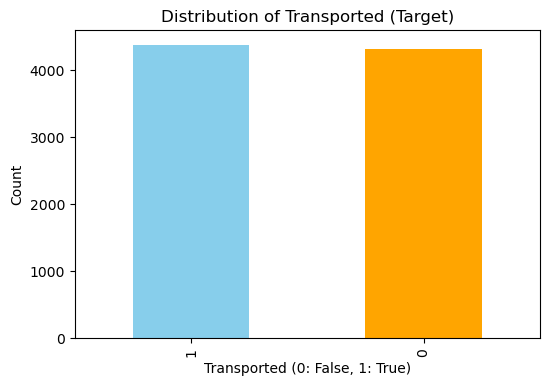

In [40]:
plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Distribution of Transported (Target)')
plt.xlabel('Transported (0: False, 1: True)')
plt.ylabel('Count')
plt.show()

###[시각화2]주요 수치형 데이터(Age) 분포 확인
나이(Age)와 비용 관련 데이터들의 패턴

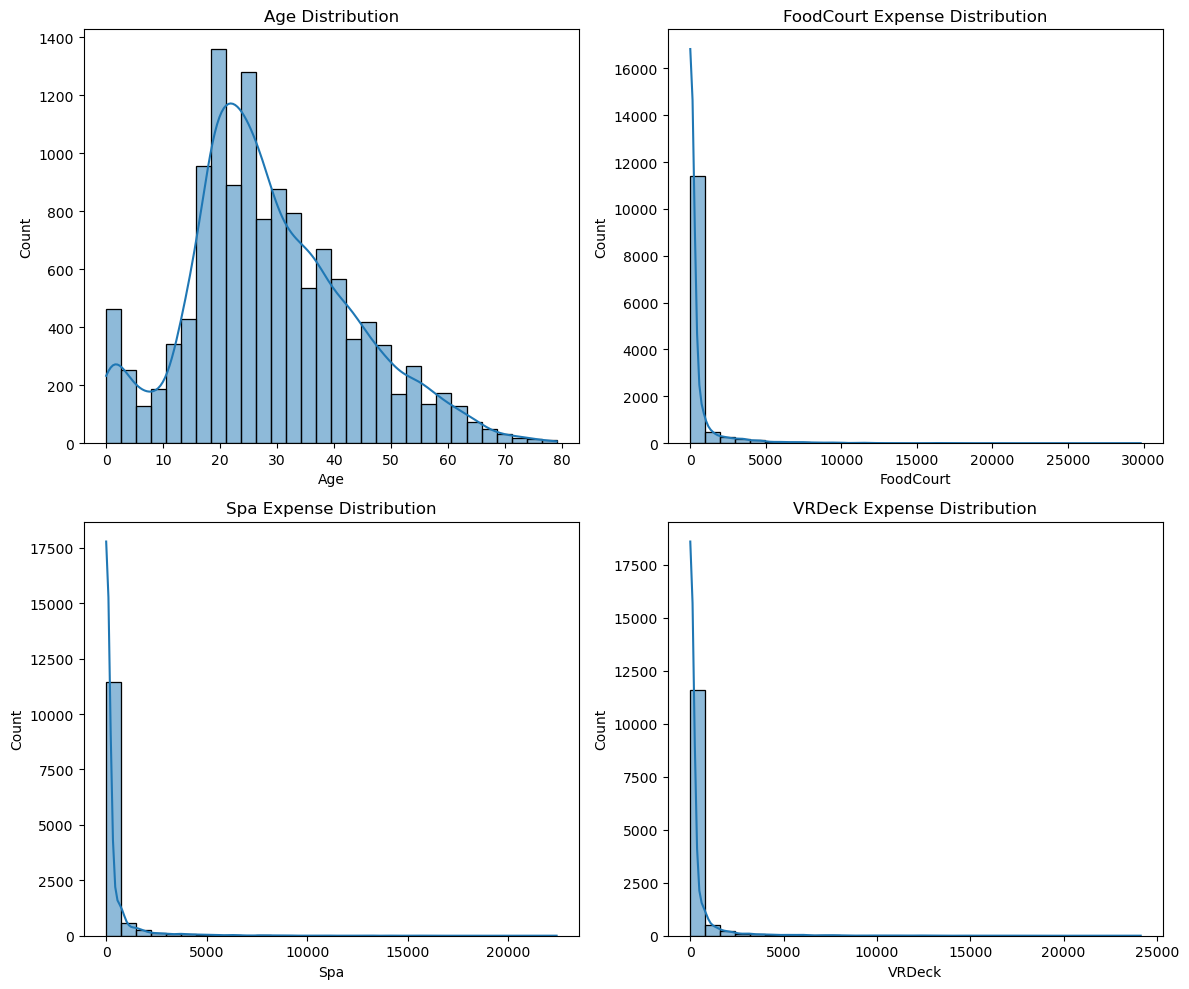

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data['Age'], bins=30, kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Age Distribution')
sns.histplot(data['FoodCourt'], bins=30, kde=True, ax=ax[0, 1])
ax[0, 1].set_title('FoodCourt Expense Distribution')
sns.histplot(data['Spa'], bins=30, kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Spa Expense Distribution')
sns.histplot(data['VRDeck'], bins=30, kde=True, ax=ax[1, 1])
ax[1, 1].set_title('VRDeck Expense Distribution')
plt.tight_layout()
plt.show()

##데이터 전처리(processing)
모델이 학습할 수 있도록 데이터를 정제

In [42]:
###[전처리 1] Cabin 컬럼 분리 ('Deck/Num/Side')

In [43]:
data[["Deck", "Cabin_num", "Side"]] = data["Cabin"].str.split("/", expand=True)
del data['Cabin'] # 원본 삭제
print("\n✅ Cabin 컬럼 분리 완료 (Deck, Cabin_num, Side 생성)")


✅ Cabin 컬럼 분리 완료 (Deck, Cabin_num, Side 생성)


###[전처리 2] 데이터 타입 변환 (Bool -> Int)
불(Bool) 데이터(True/False)를 모델이 인식할 수 있도록 정수형(0, 1)으로 변환

In [44]:
bool_cols = ['CryoSleep', 'VIP']
for col in bool_cols:
    data[col] = data[col].fillna(False).astype(int)
print("✅ 불(Bool) 데이터를 정수형(0, 1)으로 변환 완료")

✅ 불(Bool) 데이터를 정수형(0, 1)으로 변환 완료


/tmp/ipykernel_764/841433212.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False).astype(int)
/tmp/ipykernel_764/841433212.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False).astype(int)


###[전처리 3] 결측치 처리
수치형은 중앙값(median), 범주형은 최빈값(mode)

In [45]:
for col in data.columns:
    if data[col].dtype in ['float64', 'int64']:
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])
print("✅ 모든 결측치 처리 완료")

✅ 모든 결측치 처리 완료


Cabin 컬럼의 'Deck/Num/Side' 형식을 분리하여 Deck, Cabin_num, Side라는 3개의 새로운 컬럼으로 만들면 모델 학습에 더 도움됨.

###[전처리4]불필요한 식별자 제거 및 인코딩

In [46]:
del data['PassengerId']
del data['Name']

문자열(Deck, Side 등)을 숫자로 바꾸는 원-핫 인코딩

In [47]:
data = pd.get_dummies(data)

3. 데이터 다시 나누기 (학습용 x, 제출용 sub)

In [49]:
sub = data.iloc[train_len:, :]
x = data.iloc[:train_len, :]
print(f"\n🚀 전처리 최종 완료! 학습 데이터 크기: {x.shape}")


🚀 전처리 최종 완료! 학습 데이터 크기: (8693, 1918)


7. 데이터셋 분할 (검증용 8:2)
모델이 공부를 잘했는지 시험해보기 위해 20%를 떼어놓기

In [51]:
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

##모델 선택 및 학습

###모델 선택: RandomForestClassifier
이번엔 분류(Classifier) 모델을 쓴다.

In [52]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##학습 및 검증: 전체 데이터를 학습용(Training)과 검증용(Validation)으로 나누어 모델을 학습시키고 성능을 평가

In [53]:
y_pred = model.predict(X_val)
print(f"\n✅ 검증 데이터 정확도: {accuracy_score(y_val, y_pred):.4f}")


✅ 검증 데이터 정확도: 0.7890


In [54]:
predictions = model.predict(sub)
output = pd.DataFrame({'PassengerId': sub_id, 'Transported': predictions.astype(bool)})
output.to_csv('/home/jovyan/work/spaceship-titanic/submission.csv', index=False)

print("🎉 모든 과정 완료! submission.csv 파일이 생성되었습니다.")

🎉 모든 과정 완료! submission.csv 파일이 생성되었습니다.


회고 내용: 너무 어렵다. 다시 공부가 필요할 것 같다. 왜 이렇게 어려운지.

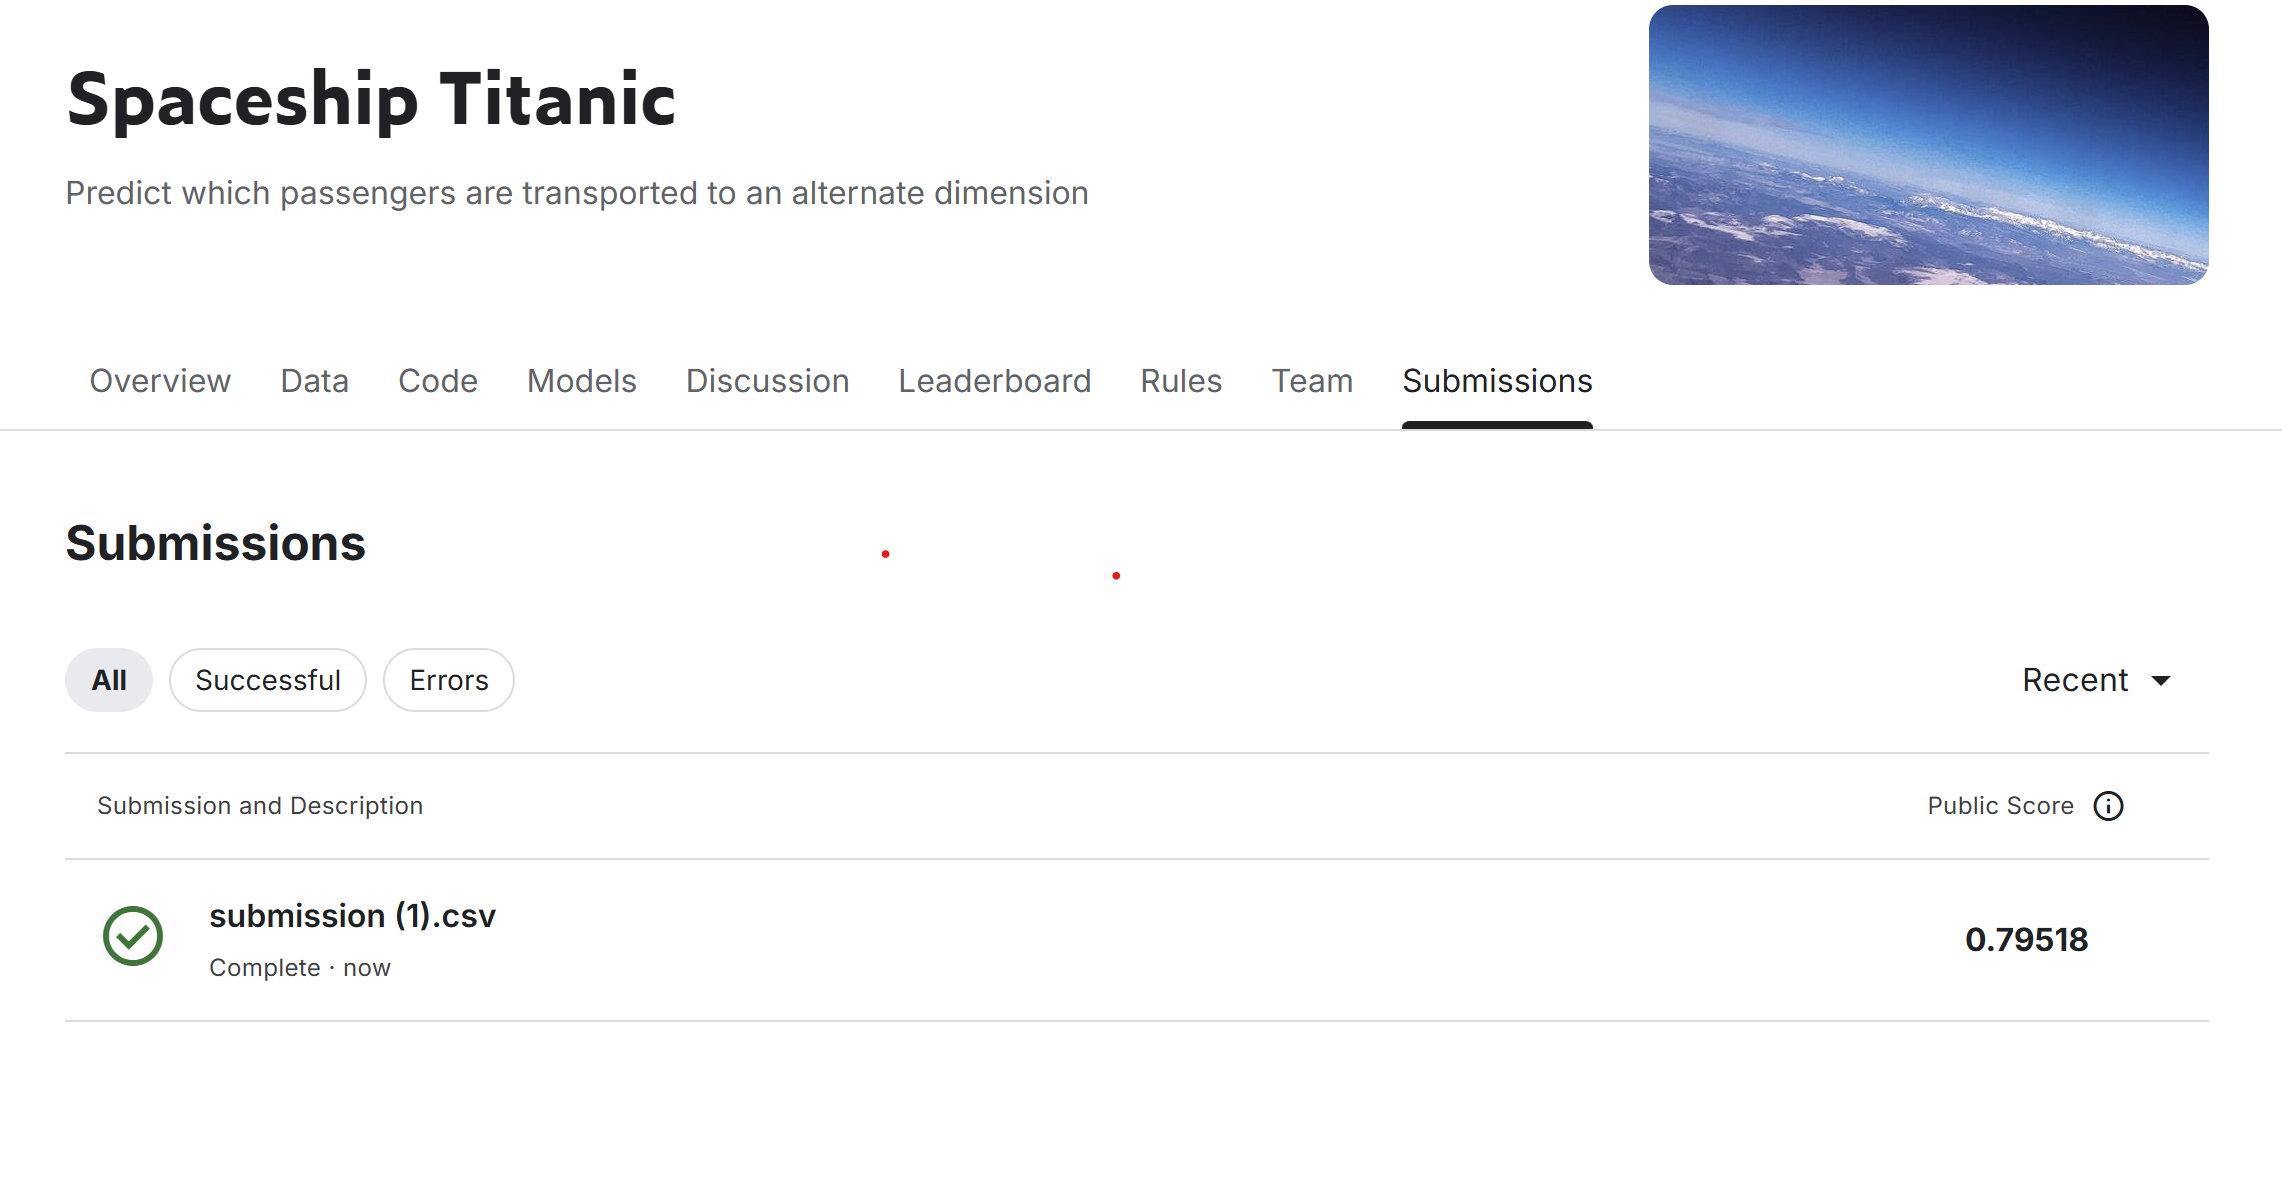